# SegFormer PeruSat-1

Cuaderno de entrenamiento, validacion, prueba y analisis de posprocesamiento para segmentacion de edificaciones con PeruSat-1.

## 1. Entorno, Drive y datos

Preparacion inicial del entorno de Colab, montaje de Google Drive y descompresion del dataset.

### 1.1 Exploracion, montaje de Drive y descompresion

Revision opcional del almacenamiento, conexion a Drive y extraccion de archivos del dataset.

In [ ]:
#!du -h --max-depth=1 /content | sort -hr

In [ ]:
# Optional Colab Drive mount for private files.
# Uncomment only when running in Colab and your files are stored outside this repository.
# from google.colab import drive
# drive.mount("<COLAB_DRIVE_MOUNT>")

Mounted at <COLAB_DRIVE>


In [ ]:
from pathlib import Path
import os

DATA_ROOT = Path(os.environ.get("PERUSAT1_DATA_ROOT", "/content/Dataset"))
RUN_DIR = Path(os.environ.get("PERUSAT1_RUN_DIR", "/content/segformer_runs"))
RESUME_CKPT_PATH = os.environ.get("PERUSAT1_RESUME_CKPT_PATH") or None
BEST_CKPT_PATH = os.environ.get("PERUSAT1_BEST_CKPT_PATH") or None

RUN_DIR.mkdir(parents=True, exist_ok=True)

# Optional dataset extraction for private/local use. The archive is not distributed in this repository.
# !mkdir -p /content/Dataset
# !unrar x -o+ "/path/to/private_dataset_archive.rar" /content/Dataset/

Se han truncado las últimas 5000 líneas del flujo de salida.
Extracting  /content/Dataset/val/masks/mask_IMG_PER1_20230922151914_ORT_PMS_010438_001028.tif      99%  OK 
Extracting  /content/Dataset/val/masks/mask_IMG_PER1_20230922151914_ORT_PMS_010438_001029.tif      99%  OK 
Extracting  /content/Dataset/val/masks/mask_IMG_PER1_20230922151914_ORT_PMS_010438_001030.tif      99%  OK 
Extracting  /content/Dataset/val/masks/mask_IMG_PER1_20230922151914_ORT_PMS_010438_001031.tif      99%  OK 
Extracting  /content/Dataset/val/masks/mask_IMG_PER1_20230922151914_ORT_PMS_010438_001032.tif      99%  OK 
Extracting  /content/Dataset/val/masks/mask_IMG_PER1_20230922151914_ORT_PMS_010438_001033.tif      99%  OK 
Extracting  /content/Dataset/val/masks/mask_IMG_PER1_20230922151914_ORT_PMS_010438_001034.tif      99%  OK 
Extracting  /content/Dataset/val/masks/mask_IMG_PER1_20230922151914_ORT_PMS_010438_001035.tif      99%  OK 
Ext

### 1.2 Instalacion de dependencias

Paquetes necesarios para ejecutar Lightning y SegFormer en el entorno de Colab.

In [ ]:
!pip install lightning
!pip install git+https://github.com/qubvel/segmentation_models.pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 65.6 MB/s eta 0:00:00
  Cloning https://github.com/qubvel/segmentation_models.pytorch to /tmp/pip-req-build-jjjqbc40
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/segmentation_models.pytorch /tmp/pip-req-build-jjjqbc40
  Resolved https://github.com/qubvel/segmentation_models.pytorch to commit 1fd0be2aa961eb885f06ed492cfb26f9f4c2e231
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for segmentation_models_pytorch: filename=segmentation_models_pytorch-0.5.1.dev0-py3-none-any.whl size=157855 sha256=f2beb9b533476bd49fba0da0eae7dec14d0df13355ecd73adfb73ec3df747

## 2. Preparacion de datos

Imports, constantes de mascara, clase dataset, aumentaciones y loaders.

### 2.1 Imports y constantes de mascara

Librerias principales y valores usados para interpretar las mascaras.

In [ ]:
import os
import cv2
import numpy as np
import albumentations as A
import torch
import pytorch_lightning as pl
import segmentation_models_pytorch as smp
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.utils.data import Dataset as BaseDataset
import rasterio

# Clases de la máscara (desde raster_to_tile.py)
NOINFO_VALUE = 0
BACKGROUND   = 1
BUILDING     = 3
EXCLUDE      = 10

### 2.2 Dataset personalizado

Clase que lee imagenes normalizadas, mascaras y pixeles validos para entrenamiento supervisado.

In [ ]:
class Dataset(BaseDataset):
    """
    Devuelve:
      image: float32 (C,H,W) en [0,1]
      y:     float32 (1,H,W) en {0,1}
      valid: float32 (1,H,W) en {0,1}
    """
    def __init__(
        self,
        images_dir, #directorio de imágenes
        masks_dir, #directorio de máscaras
        spatial_augmentation=None, #aumentaciones espaciales
        rgb_augmentation=None #aumentaciones RGB
    ):
        self.ids = os.listdir(images_dir) # extraer id de las imágenes del directorio
        self.images_fps = [os.path.join(images_dir, image_id) for image_id in self.ids] #lista de las imágenes RGB
        self.masks_fps = [os.path.join(masks_dir, image_id.replace("img_", "mask_")) for image_id in self.ids] #lista de las máscaras
        self.spatial_augmentation = spatial_augmentation #activar aumentación espacial
        self.rgb_augmentation = rgb_augmentation #activar aumentación RGB

    def __len__(self):
        return len(self.ids) #leer la cantidad de elementos

    def __getitem__(self, i):

        with rasterio.open(self.images_fps[i]) as src:         #Leer imagen con rasterio
            image = src.read([1, 2, 3])   # (3, H, W) Se leerá las 3 primeras capas de la imagenes (3 primeros canales, Height y Weight)

        image = np.transpose(image, (1, 2, 0))   # (H, W, 3) # Transponer imagen para que tenga el formato (Height, Weight y 3 Canales)

        with rasterio.open(self.masks_fps[i]) as src:         # Leer máscara con rasterio también
            mask = src.read(1)   # (H, W) #Se leerá solo la primera capa (la única) de la máscara

        if mask is None:
            raise FileNotFoundError(self.masks_fps[i])  #AVISA si no se encuentra alguna máscara

        valid = ((mask != NOINFO_VALUE) & (mask != EXCLUDE)).astype(np.uint8) #CREA UNA CAPA DE MÁSCARA DE PÍXELES VÁLIDOS/ 1S PÍXELES VÁLIDOS, 0S PÍXELES INVÁLIDOS
        y = (mask == BUILDING).astype(np.uint8)  #CREA UNA CAPA DE 1s en DONDE SE DETECTA EDIFICIOS, 0S LO DEMÁS
        y[valid == 0] = 0  # REDUNDANTE si los códigos inválidos no son BUILDING; se deja como limpieza defensiva.

        if self.spatial_augmentation: # SI ES QUE SE ACTIVA LA AUMENTACIÓN ESPACIAL SE ASIGNARÁ EL MÉTODO QUE ALBUMENTATIONS (osea, pudo haber sido directamente valid == 0)
            sample = self.spatial_augmentation(image=image, mask=y, valid=valid)  #SPATIAL AUGMENTATION
            image = sample["image"]
            y = sample["mask"]
            valid = sample["valid"]

        if self.rgb_augmentation:
            image = self.rgb_augmentation(image=image)["image"] #SI SE ACTIVA LA AUMENTACIÓN RGB

        image = np.transpose(image, (2, 0, 1)).astype(np.float32) / 255.0   #SE REALIZA EL REESCALAMIENTO ENTRE 0-1

        y = y.astype(np.float32)[None, :, :]  #SE CONVIERTE A FLOAT 32
        valid = valid.astype(np.float32)[None, :, :] #SE CONVIERTE A FLOAT 32

        #SE ENTREGA (IMAGEN REESCALADA ENTRE 255, MASCARA DE CONSTRUCCIONES, MASCARA DE PÍXELES VALIDOS)
        return image, y, valid

### 2.3 Aumentacion de datos

Transformaciones espaciales y RGB usadas durante entrenamiento, validacion y prueba.

In [ ]:
def get_training_spatial_augmentation(): #AUMENTACIÓN ESPACIAL
    train_transform = [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(
            scale_limit=0.10,
            rotate_limit=0,
            shift_limit=0.05,
            p=0.7,
            border_mode=cv2.BORDER_CONSTANT
        ),
        A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT)
    ]
    return A.Compose(train_transform, additional_targets={"valid": "mask"})


def get_training_rgb_augmentation(): #AUMENTACIÓN RGB
    return A.Compose([
        A.RandomBrightnessContrast(
            brightness_limit=0.08,
            contrast_limit=0.08,
            p=0.25
        ),
        A.GaussianBlur(blur_limit=(3, 3), p=0.10),
    ])


def get_validation_augmentation(): #AUMENTACIÓN DE VALIDACIÓN DE
    test_transform = [
        A.PadIfNeeded(512, 512, border_mode=cv2.BORDER_CONSTANT),
    ]
    return A.Compose(test_transform, additional_targets={"valid": "mask"})

### 2.4 Construccion de datasets

Instancias para train, valid y test a partir de las carpetas de imagenes y mascaras.

In [ ]:
# TRAIN DATASET
train_dataset = Dataset(
    str(DATA_ROOT / "train" / "images_norm"),
    str(DATA_ROOT / "train" / "masks"),
    spatial_augmentation=get_training_spatial_augmentation(),
    rgb_augmentation=get_training_rgb_augmentation(),
)

# VALID DATASET
valid_dataset = Dataset(
    str(DATA_ROOT / "val" / "images_norm"),
    str(DATA_ROOT / "val" / "masks"),
    spatial_augmentation=get_validation_augmentation(),
    rgb_augmentation=None,
)

# TEST DATASET
test_dataset = Dataset(
    str(DATA_ROOT / "test" / "images_norm"),
    str(DATA_ROOT / "test" / "masks"),
    spatial_augmentation=get_validation_augmentation(),
    rgb_augmentation=None,
)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### 2.5 Rebalanceo por hard mining

Repeticion controlada de origenes especificos para reforzar ejemplos dificiles durante el entrenamiento.

In [ ]:
#"HARD MINING"

from collections import defaultdict
from torch.utils.data import DataLoader, Subset, ConcatDataset

# Cuántas COPIAS EXTRA quieres añadir por origen
# 1 => total 2 veces si ya existe una vez en train
# 2 => total 3 veces si ya existe una vez en train
repeat_map = {
    "Recortada_IMG_PER1_20220913145908_ORT_PMS_000659": 1,
    "IMG_PER1_20230531145858_ORT_PMS_000054_repasado_sara": 1,
    "IMG_PER1_20221119153338_ORT_PMS_000055_rural": 2,
    "IMG_PER1_20240816153927_ORT_PMS_000137_repasado_rural": 1,
    "IMG_PER1_20250302151959_ORT_PMS_000376_rural": 1,
    "IMG_PER1_20250302151959_ORT_PMS_000376_urbano":1,
    "IMG_PER1_20161031153102_ORT_PMS_001517_repasado_lambayeque_mar_urbano":1,
}

# Buscar índices del train_dataset que pertenezcan a cada origen
origin_to_indices = defaultdict(list)

for i, tile_id in enumerate(train_dataset.ids):
    tile_name = tile_id.lower()
    for origin_name in repeat_map.keys():
        if origin_name.lower() in tile_name:
            origin_to_indices[origin_name].append(i)

# Verificación rápida
print("=== Conteo de parches encontrados por origen en train ===")
for origin_name in repeat_map.keys():
    n = len(origin_to_indices[origin_name])
    print(f"{origin_name}: {n} parches encontrados")

# Armar subsets extra según repeticiones pedidas
extra_subsets = []
for origin_name, n_extra_copies in repeat_map.items():
    idxs = origin_to_indices[origin_name]

    if len(idxs) == 0:
        print(f"[AVISO] No se encontraron parches de train para: {origin_name}")
        continue

    hard_subset = Subset(train_dataset, idxs)

    for _ in range(n_extra_copies):
        extra_subsets.append(hard_subset)

# Dataset final = original + copias extra de los orígenes difíciles
if len(extra_subsets) > 0:
    train_dataset_balanced = ConcatDataset([train_dataset] + extra_subsets)
else:
    train_dataset_balanced = train_dataset

print("Tamaño train original:", len(train_dataset))
print("Tamaño train final   :", len(train_dataset_balanced))

=== Conteo de parches encontrados por origen en train ===
Recortada_IMG_PER1_20220913145908_ORT_PMS_000659: 1023 parches encontrados
IMG_PER1_20230531145858_ORT_PMS_000054_repasado_sara: 1836 parches encontrados
IMG_PER1_20221119153338_ORT_PMS_000055_rural: 2543 parches encontrados
IMG_PER1_20240816153927_ORT_PMS_000137_repasado_rural: 1697 parches encontrados
IMG_PER1_20250302151959_ORT_PMS_000376_rural: 1371 parches encontrados
IMG_PER1_20250302151959_ORT_PMS_000376_urbano: 83 parches encontrados
IMG_PER1_20161031153102_ORT_PMS_001517_repasado_lambayeque_mar_urbano: 64 parches encontrados
Tamaño train original: 31295
Tamaño train final   : 42455


### 2.6 DataLoaders

Configuracion de lotes, paralelismo y lectura eficiente para cada particion.

In [ ]:
#DATALOADERS

train_loader = DataLoader(
    train_dataset_balanced, batch_size=96, shuffle=True,
    num_workers=8, pin_memory=True, persistent_workers=True,
    prefetch_factor=2
)

valid_loader = DataLoader(
    valid_dataset, batch_size=64, shuffle=False,
    num_workers=8, pin_memory=True, persistent_workers=True,
    prefetch_factor=2
)

test_loader = DataLoader(
    test_dataset, batch_size=16, shuffle=False,
    num_workers=8, pin_memory=True, persistent_workers=True,
    prefetch_factor=2
)


## 3. Modelo y entrenamiento

Definicion del numero de epocas, modulo Lightning, callbacks, trainer y ejecucion del entrenamiento.

### 3.1 Numero de epocas

Parametro principal que controla la duracion maxima del entrenamiento.

In [ ]:
#SE CONFIGURA EL NÚMERO DE ÉPOCAS
MAX_EPOCHS = 150


### 3.2 LightningModule SegFormer

Arquitectura, perdidas, metricas y pasos de entrenamiento/validacion/prueba.

In [ ]:
import pytorch_lightning as pl
import segmentation_models_pytorch as smp
import torch
import torch.nn.functional as F
from torch.optim import lr_scheduler
from torchmetrics.classification import BinaryJaccardIndex, BinaryF1Score, BinaryFBetaScore, BinaryPrecision, BinaryRecall


def _gaussian_kernel2d(kernel_size: int, sigma: float, device, dtype):
    ax = torch.arange(kernel_size, device=device, dtype=dtype) - (kernel_size - 1) / 2.0
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    k = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    k = k / (k.sum() + 1e-12)
    return k.view(1, 1, kernel_size, kernel_size)


def boundary_weight_map(y01: torch.Tensor, valid: torch.Tensor, sigma=3.0, c=200.0, kernel_size=13):
    """
    y01:   (B,1,H,W) float {0,1}
    valid: (B,1,H,W) float {0,1}
    retorna w: (B,1,H,W) float, con w=0 en pixeles ignorados
    """
    # Asegurar que bordes se calculen solo en zona válida
    y = y01 * valid

    # Morph gradient: dilate - erode
    dil = F.max_pool2d(y, kernel_size=3, stride=1, padding=1)
    ero = 1.0 - F.max_pool2d(1.0 - y, kernel_size=3, stride=1, padding=1)
    edge = (dil - ero).clamp(0, 1)

    k = _gaussian_kernel2d(kernel_size, sigma, device=y.device, dtype=y.dtype)
    blurred = F.conv2d(edge, k, padding=kernel_size // 2)

    w = (1.0 + c * blurred) * valid
    return w


def weighted_tversky_loss(logits, y, weight_map, alpha=0.7, beta=0.3, eps=1e-6):
    """
    alpha: penaliza FP
    beta:  penaliza FN
    weight_map: mapa de pesos pixel a pixel
    """
    p = torch.sigmoid(logits)
    y = y.float()
    weight_map = weight_map.float()

    tp = (weight_map * p * y).sum(dim=(1, 2, 3))
    fp = (weight_map * p * (1 - y)).sum(dim=(1, 2, 3))
    fn = (weight_map * (1 - p) * y).sum(dim=(1, 2, 3))

    tversky = (tp + eps) / (tp + alpha * fp + beta * fn + eps)
    return 1.0 - tversky.mean()


def focal_loss(logits, y, weight_map, gamma=2.0, alpha=0.75, eps=1e-6):
    p = torch.sigmoid(logits)
    bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
    p_t = p * y + (1 - p) * (1 - y)
    alpha_t = alpha * y + (1 - alpha) * (1 - y)
    focal = alpha_t * (1 - p_t) ** gamma * bce
    return (focal * weight_map).sum() / (weight_map.sum() + eps)

class BuildingModel(pl.LightningModule):
    def __init__(
        self,
        arch,
        encoder_name,
        in_channels,
        out_classes=1,
        lr=5e-5,
        encoder_weights="imagenet",
        use_boundary_weighting=True,
        bw_sigma=3.0,
        bw_c=40,
        bw_kernel_size=13,
        **kwargs
    ):
        super().__init__()
        self.save_hyperparameters()

        self.model = smp.create_model(
            arch,
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=in_channels,
            classes=1,
            **kwargs,
        )

        params = smp.encoders.get_preprocessing_params(encoder_name)
        self.register_buffer("rgb_mean", torch.tensor(params["mean"]).view(1, 3, 1, 1))
        self.register_buffer("rgb_std", torch.tensor(params["std"]).view(1, 3, 1, 1))

        encoder_out_channels = self.model.encoder.out_channels[-1]
        self.tile_classifier = torch.nn.Sequential(
            torch.nn.AdaptiveAvgPool2d(1),
            torch.nn.Flatten(),
            torch.nn.Linear(encoder_out_channels, 1)
        )
        self.aux_bce = torch.nn.BCEWithLogitsLoss()

        for stage in ["train", "valid", "test"]:
            setattr(self, f"{stage}_iou", BinaryJaccardIndex())
            setattr(self, f"{stage}_f1", BinaryF1Score())
            setattr(self, f"{stage}_fbeta", BinaryFBetaScore(beta=0.5))
            setattr(self, f"{stage}_precision", BinaryPrecision())
            setattr(self, f"{stage}_recall", BinaryRecall())

    def _log_segmentation_metrics(self, stage, pred, y, valid):
        valid_mask = valid.bool().view(-1)

        if valid_mask.sum() == 0:
            return

        pred_m = pred.bool().view(-1)[valid_mask]
        y_m = y.bool().view(-1)[valid_mask]

        metric_names = ["iou", "f1", "fbeta", "precision", "recall"]
        for name in metric_names:
            metric = getattr(self, f"{stage}_{name}")
            metric.update(pred_m, y_m)
            self.log(
                f"{stage}_{name}",
                metric,
                prog_bar=name in ["iou", "f1", "fbeta"],
                on_step=False,
                on_epoch=True,
            )

    def forward(self, image, valid=None):
        image = (image - self.rgb_mean) / self.rgb_std

        if valid is not None:
            image = image * valid

        features = self.model.encoder(image)
        decoder_output = self.model.decoder(features)
        seg_logits = self.model.segmentation_head(decoder_output)
        tile_logit = self.tile_classifier(features[-1])
        return seg_logits, tile_logit

    def shared_step(self, batch, stage):
        image, y, valid = batch
        image = image.float()
        y = y.float()
        valid = valid.float()

        logits, tile_logit = self.forward(image, valid)

        has_building = (y * valid).amax(dim=(1, 2, 3)).unsqueeze(1)

        if self.hparams.use_boundary_weighting:
            weight_map = boundary_weight_map(
                y, valid,
                sigma=self.hparams.bw_sigma,
                c=self.hparams.bw_c,
                kernel_size=self.hparams.bw_kernel_size
            )
        else:
            weight_map = valid

        floss = focal_loss(
            logits, y, weight_map,
            gamma=2.0,
            alpha=0.25
        )

        tloss = weighted_tversky_loss(
            logits, y, weight_map,
            alpha=0.7,
            beta=0.3
        )

        aux_loss = self.aux_bce(tile_logit, has_building)

        # pesos: aquí haces que el efecto se sienta
        loss = 2.0 * floss + 1.0 * tloss + 0.2 * aux_loss

        pred = torch.sigmoid(logits) > 0.5

        self.log(f"{stage}_loss",      loss,      prog_bar=True,  on_step=False, on_epoch=True)
        self.log(f"{stage}_floss",     floss,     prog_bar=False, on_step=False, on_epoch=True)
        self.log(f"{stage}_tloss",     tloss,     prog_bar=False, on_step=False, on_epoch=True)
        self.log(f"{stage}_aux_loss",  aux_loss,  prog_bar=False, on_step=False, on_epoch=True)
        self.log(f"{stage}_wmean",     weight_map.mean(), prog_bar=False, on_step=False, on_epoch=True)
        self.log(f"{stage}_wmax",      weight_map.max(),  prog_bar=False, on_step=False, on_epoch=True)

        self._log_segmentation_metrics(stage, pred, y, valid)

        return loss


    def training_step(self, batch, batch_idx):
        return self.shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self.shared_step(batch, "valid")

    def test_step(self, batch, batch_idx):
        self.shared_step(batch, "test")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=5e-5, weight_decay=1e-4)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",        # si monitoreas valid_fbeta / valid_iou
            factor=0.5,
            patience=4,
            threshold=0.002,
            threshold_mode="rel",
            cooldown=1,
            min_lr=1e-6
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "valid_fbeta",
                "interval": "epoch",
                "frequency": 1,
            },
        }

### 3.3 Callbacks, logger y checkpointing

Configuracion de guardado del mejor modelo, early stopping y registro de metricas.

In [ ]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger

In [ ]:
ckpt_dir = RUN_DIR / "checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)

checkpoint_callback = ModelCheckpoint(
    dirpath=str(ckpt_dir),
    monitor="valid_fbeta",
    mode="max",
    save_top_k=1,
    save_last=True,
    save_on_exception=True,
    save_weights_only=False,
    filename="best-segformer-mitb2-3ch-{epoch:02d}-{valid_fbeta:.4f}",
    auto_insert_metric_name=False
)

early_stop_callback = EarlyStopping(
    monitor="valid_fbeta",
    mode="max",
    patience=30,
    min_delta=0.0005,
    verbose=True
)

model = BuildingModel(
    "Segformer",
    "mit_b2",
    in_channels=3,
    out_classes=1,
    lr=5e-5,
    encoder_weights="imagenet",
    use_boundary_weighting=True,
    bw_sigma=3.0,
    bw_c=40,
    bw_kernel_size=13
    )

log_dir = RUN_DIR / "logs_segformer"

csv_logger = CSVLogger(
    save_dir=str(log_dir),
    name="segformer_mitb2_3ch"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

### 3.4 Precision numerica y trainer

Ajustes de precision y creacion del objeto `Trainer` para GPU.

In [ ]:
import torch
torch.set_float32_matmul_precision("high")

In [ ]:
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    callbacks=[checkpoint_callback, early_stop_callback],
    accelerator="gpu",
    devices=1,
    precision="16-mixed",
    log_every_n_steps=1,
    logger=csv_logger
)

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### 3.5 Entrenamiento del modelo

Envio del modelo al dispositivo y ejecucion de `trainer.fit`.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

In [ ]:
trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=valid_loader,
    ckpt_path=RESUME_CKPT_PATH
)

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory <COLAB_DRIVE>/.shortcut-targets-by-id/1b8wp1EnPIBLfC-p1by_o7-Lhlr99zy76/<PRIVATE_PROJECT_DIR>/Pytorch/VersionParaPaper exists and is not empty.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at <PRIVATE_RUN_DIR>/best-segformer-mitb2-3ch-79-0.8080.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model           │ Segformer          │ 24.7 M │ train │     0 │
│ 1  │ tile_classifier │ Sequential         │    513 │ train │     0 │
│ 2  │ aux_bce         │ BCEWithLogitsLoss  │      0 │ train │     0 │
│ 3  │ train_iou       │ BinaryJaccardIndex │      0 │ train │     0 │
│ 4  │ train_f1        │ BinaryF1Score      │      0 │ train │     0 │
│ 5  │ train_fbeta     │ BinaryFBetaScore   │      0 │ train │     0 │
│ 6  │ train_precision │ BinaryPrecision    │      0 │ train │     0 │
│ 7  │ train_recall    │ BinaryRecall       │      0 │ train │     0 │
│ 8  │ valid_iou       │ BinaryJaccardIndex │      0 │ train │     0 │
│ 9  │ valid_f1        │ BinaryF1Score      │      0 │ train │     0 │
│ 10 │ valid_fbeta     │ BinaryFBetaScore   │      0 │ train │     0 │
│ 11 │ valid_precision │ BinaryPrecision    │      0 │ train │     0 │
│ 12 │ valid_recall    │ BinaryRecall       │      0 │ train │     0 │
│ 13 │ test_iou        │ BinaryJaccardIndex │      0 │ train │     0 │
│ 14 │ test_f1         │ BinaryF1Score      │      0 │ train │     0 │
│ 15 │ test_fbeta      │ BinaryFBetaScore   │      0 │ train │     0 │
│ 16 │ test_precision  │ BinaryPrecision    │      0 │ train │     0 │
│ 17 │ test_recall     │ BinaryRecall       │      0 │ train │     0 │
└────┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 24.7 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.7 M                                                                                               
Total estimated model params size (MB): 98.892                                                                     
Modules in train mode: 365                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint at <PRIVATE_RUN_DIR>/best-segformer-mitb2-3ch-79-0.8080.ckpt


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric valid_fbeta did not improve in the last 30 records. Best score: 0.808. Signaling Trainer to stop.


## 4. Mejor checkpoint y evaluacion base

Carga del checkpoint seleccionado y evaluacion inicial sobre validacion y test.

In [ ]:
if BEST_CKPT_PATH is None:
    raise ValueError("Set PERUSAT1_BEST_CKPT_PATH to the checkpoint you want to evaluate.")

model2 = BuildingModel.load_from_checkpoint(BEST_CKPT_PATH)  # tu clase LightningModule
model2.eval().cuda()

trainer2 = pl.Trainer(accelerator="gpu", devices=1, precision="16-mixed")

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### 4.1 Validacion y prueba sin posproceso

Metricas base del checkpoint seleccionado antes de aplicar reglas de posprocesamiento.

In [ ]:
#Datos de validación sin posproceso
trainer2.validate(model2, dataloaders=valid_loader)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      valid_aux_loss       │    0.17487485706806183    │
│         valid_f1          │    0.7781699895858765     │
│        valid_fbeta        │    0.8084335327148438     │
│        valid_floss        │   0.005999129265546799    │
│         valid_iou         │    0.6368889212608337     │
│        valid_loss         │    0.8732283115386963     │
│      valid_precision      │    0.8299517631530762     │
│       valid_recall        │    0.7324702143669128     │
│        valid_tloss        │    0.8262551426887512     │
│        valid_wmax         │    27.264495849609375     │
│        valid_wmean        │    0.9637530446052551     │
└───────────────────────────┴───────────────────────────┘

[{'valid_loss': 0.8732283115386963,
  'valid_floss': 0.005999129265546799,
  'valid_tloss': 0.8262551426887512,
  'valid_aux_loss': 0.17487485706806183,
  'valid_wmean': 0.9637530446052551,
  'valid_wmax': 27.264495849609375,
  'valid_iou': 0.6368889212608337,
  'valid_f1': 0.7781699895858765,
  'valid_fbeta': 0.8084335327148438,
  'valid_precision': 0.8299517631530762,
  'valid_recall': 0.7324702143669128}]

In [ ]:
#Datos de test sin posproceso
trainer2.test(model2, dataloaders=test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_aux_loss       │    0.1708468496799469     │
│          test_f1          │    0.7322152256965637     │
│        test_fbeta         │     0.78769451379776      │
│        test_floss         │    0.00790236983448267    │
│         test_iou          │    0.5775548815727234     │
│         test_loss         │     0.864004909992218     │
│      test_precision       │    0.8295999765396118     │
│        test_recall        │    0.6552921533584595     │
│        test_tloss         │    0.8140304088592529     │
│         test_wmax         │    25.601730346679688     │
│        test_wmean         │    1.0028151273727417     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.864004909992218,
  'test_floss': 0.00790236983448267,
  'test_tloss': 0.8140304088592529,
  'test_aux_loss': 0.1708468496799469,
  'test_wmean': 1.0028151273727417,
  'test_wmax': 25.601730346679688,
  'test_iou': 0.5775548815727234,
  'test_f1': 0.7322152256965637,
  'test_fbeta': 0.78769451379776,
  'test_precision': 0.8295999765396118,
  'test_recall': 0.6552921533584595}]

### 4.2 Exportacion de pesos

Guardado del `state_dict` del modelo entrenado para uso posterior.

In [ ]:
import torch

export_path = RUN_DIR / "best-segformer-mitb2-3ch-public.pth"
torch.save(model2.model.state_dict(), export_path)
print(f"Saved model weights to: {export_path}")

## 5. Evaluacion por objetos y posprocesamiento

Funciones para medir resultados por pixeles y objetos, comparar configuraciones y seleccionar el mejor posproceso.

In [ ]:
import os
import re
from collections import defaultdict
from itertools import product

import numpy as np
import pandas as pd
import torch
from torchmetrics.classification import (
    BinaryFBetaScore,
    BinaryF1Score,
    BinaryJaccardIndex,
    BinaryPrecision,
    BinaryRecall,
)

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

try:
    import cv2
except Exception:
    cv2 = None

try:
    from skimage.morphology import opening as skimage_opening
    from skimage.morphology import remove_small_objects
except Exception:
    skimage_opening = None
    remove_small_objects = None

try:
    from rasterio.features import sieve as rasterio_sieve
except Exception:
    rasterio_sieve = None

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
POSTPROCESS_RESULTS_DIR = ckpt_dir if "ckpt_dir" in globals() else "/content"
os.makedirs(POSTPROCESS_RESULTS_DIR, exist_ok=True)

BASELINE_THRESHOLD = 0.50
OBJECT_MATCH_MODE = "cover_gt"
OBJECT_MATCH_THRESHOLD = 0.50
METRIC_BETA = 0.5
PRIMARY_POSTPROCESS_METRIC = "valid_obj_fbeta"

# Usa un entero para pruebas rapidas. Dejalo en None para evaluar todo.
MAX_VALID_BATCHES_FOR_OBJECT_EVAL = None
MAX_TEST_BATCHES_FOR_OBJECT_EVAL = None
MAX_VALID_BATCHES_FOR_SEARCH = None
MAX_TEST_BATCHES_FOR_POSTPROCESS_EVAL = None

pd.set_option("display.max_columns", None)
print(f"Device de evaluacion: {DEVICE}")
print(f"Carpeta de resultados: {POSTPROCESS_RESULTS_DIR}")

Device de evaluacion: cuda
Carpeta de resultados: <PRIVATE_RUN_DIR>


### 5.1 Utilidades de metricas y guardado

Helpers para calcular metricas binarias, acumular resultados y exportar tablas.

In [ ]:
def _make_binary_metrics(beta=0.5, device="cpu"):
    metrics = {
        "iou": BinaryJaccardIndex(),
        "precision": BinaryPrecision(),
        "recall": BinaryRecall(),
        "f1": BinaryF1Score(),
        "fbeta": BinaryFBetaScore(beta=beta),
    }
    return {name: metric.to(device) for name, metric in metrics.items()}


def _metrics_from_binary_vectors(preds, target, prefix, beta=0.5):
    if preds.numel() == 0:
        return {f"{prefix}_{name}": np.nan for name in ["iou", "precision", "recall", "f1", "fbeta"]}

    metrics = _make_binary_metrics(beta=beta, device="cpu")
    preds = preds.detach().cpu().int()
    target = target.detach().cpu().int()
    for metric in metrics.values():
        metric.update(preds, target)

    return {
        f"{prefix}_{name}": float(metric.compute().detach().cpu())
        for name, metric in metrics.items()
    }


def _object_vectors_from_counts(tp_obj, fp_obj, fn_obj):
    tp_obj = int(tp_obj)
    fp_obj = int(fp_obj)
    fn_obj = int(fn_obj)

    preds = []
    target = []
    if tp_obj > 0:
        preds.append(torch.ones(tp_obj, dtype=torch.int64))
        target.append(torch.ones(tp_obj, dtype=torch.int64))
    if fp_obj > 0:
        preds.append(torch.ones(fp_obj, dtype=torch.int64))
        target.append(torch.zeros(fp_obj, dtype=torch.int64))
    if fn_obj > 0:
        preds.append(torch.zeros(fn_obj, dtype=torch.int64))
        target.append(torch.ones(fn_obj, dtype=torch.int64))

    if not preds:
        return torch.empty(0, dtype=torch.int64), torch.empty(0, dtype=torch.int64)
    return torch.cat(preds), torch.cat(target)


def _object_metrics_from_counts(row, prefix, beta=0.5):
    preds, target = _object_vectors_from_counts(row["tp_obj"], row["fp_obj"], row["fn_obj"])
    metrics = _metrics_from_binary_vectors(preds, target, prefix=prefix, beta=beta)
    metrics[f"{prefix}_count_error"] = int(row["n_pred_obj"] - row["n_gt_obj"])
    metrics[f"{prefix}_abs_count_error"] = abs(metrics[f"{prefix}_count_error"])
    return metrics


def _pixel_metrics_from_counts(row, prefix, beta=0.5):
    eps = 1e-6
    tp = float(row["tp_px"])
    fp = float(row["fp_px"])
    fn = float(row["fn_px"])
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    beta2 = beta ** 2
    return {
        f"{prefix}_iou": tp / (tp + fp + fn + eps),
        f"{prefix}_precision": precision,
        f"{prefix}_recall": recall,
        f"{prefix}_f1": 2 * precision * recall / (precision + recall + eps),
        f"{prefix}_fbeta": (1 + beta2) * precision * recall / (beta2 * precision + recall + eps),
    }


def save_dataframe(df, basename, output_dir=POSTPROCESS_RESULTS_DIR):
    os.makedirs(output_dir, exist_ok=True)
    csv_path = os.path.join(output_dir, f"{basename}.csv")
    xlsx_path = os.path.join(output_dir, f"{basename}.xlsx")

    df.to_csv(csv_path, index=False)
    try:
        df.to_excel(xlsx_path, index=False)
        print(f"Guardado: {csv_path}\nGuardado: {xlsx_path}")
    except Exception as exc:
        print(f"Guardado: {csv_path}")
        print(f"No se pudo guardar XLSX ({basename}): {exc}")

    return csv_path, xlsx_path

### 5.2 Configuraciones de posproceso y matching

Construccion de escenarios de umbral, apertura morfologica y filtro de area para predicciones.

In [ ]:
def build_postprocess_configs(thresholds, opening_kernels, min_area_pixels):
    configs = []
    seen = set()

    for threshold, opening_kernel, min_area_px in product(thresholds, opening_kernels, min_area_pixels):
        opening_kernel = int(opening_kernel)
        min_area_px = int(min_area_px)
        cfg = {
            "threshold": float(threshold),
            "opening_kernel": opening_kernel,
            "min_area_px": min_area_px,
            "enable_opening": bool(opening_kernel > 1),
            "enable_area_filter": bool(min_area_px > 1),
        }
        key = tuple(cfg.items())
        if key not in seen:
            seen.add(key)
            configs.append(cfg)

    return configs


def _origin_name_from_patch(patch_name):
    name = os.path.basename(str(patch_name))
    name = re.sub(r"^img_", "", name)
    name = re.sub(r"_\d{6}\.tif$", "", name)
    return name


def _dataset_patch_name(dataset, sample_idx):
    if hasattr(dataset, "ids"):
        return dataset.ids[int(sample_idx)]
    if hasattr(dataset, "dataset") and hasattr(dataset, "indices"):
        return _dataset_patch_name(dataset.dataset, dataset.indices[int(sample_idx)])
    return str(sample_idx)


def _apply_opening_to_prediction(mask, opening_kernel):
    opening_kernel = int(opening_kernel)
    if opening_kernel <= 1:
        return mask.astype(np.uint8)

    if cv2 is not None:
        kernel = np.ones((opening_kernel, opening_kernel), np.uint8)
        return cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_OPEN, kernel).astype(np.uint8)

    if skimage_opening is not None:
        footprint = np.ones((opening_kernel, opening_kernel), dtype=bool)
        return skimage_opening(mask.astype(bool), footprint=footprint).astype(np.uint8)

    from scipy import ndimage
    structure = np.ones((opening_kernel, opening_kernel), dtype=bool)
    return ndimage.binary_opening(mask.astype(bool), structure=structure).astype(np.uint8)


def _apply_area_filter_to_prediction(mask, min_area_px):
    min_area_px = int(min_area_px)
    if min_area_px <= 1:
        return mask.astype(np.uint8)

    if rasterio_sieve is not None:
        return (rasterio_sieve(mask.astype(np.uint8), size=min_area_px, connectivity=8) > 0).astype(np.uint8)

    if remove_small_objects is not None:
        return remove_small_objects(mask.astype(bool), min_size=min_area_px, connectivity=2).astype(np.uint8)

    if cv2 is not None:
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)
        cleaned = np.zeros_like(mask, dtype=np.uint8)
        for comp_id in range(1, num_labels):
            if stats[comp_id, cv2.CC_STAT_AREA] >= min_area_px:
                cleaned[labels == comp_id] = 1
        return cleaned

    raise ImportError("No hay backend disponible para filtrar area de predicciones.")


def postprocess_prediction_mask(pred_mask, valid_mask, cfg):
    # Solo se filtra la prediccion. El ground truth no pasa por opening ni area filter.
    valid_mask = (valid_mask > 0).astype(np.uint8)
    cleaned = (pred_mask > 0).astype(np.uint8) * valid_mask

    if cfg.get("enable_opening", False):
        cleaned = _apply_opening_to_prediction(cleaned, cfg.get("opening_kernel", 0)) * valid_mask

    if cfg.get("enable_area_filter", False):
        cleaned = _apply_area_filter_to_prediction(cleaned, cfg.get("min_area_px", 0)) * valid_mask

    return (cleaned > 0).astype(np.uint8) * valid_mask


def _label_components(mask):
    mask = (mask > 0).astype(np.uint8)
    try:
        from skimage.measure import label
        labels = label(mask.astype(bool), connectivity=2).astype(np.int32)
    except Exception:
        from scipy import ndimage
        structure = np.ones((3, 3), dtype=np.uint8)
        labels, _ = ndimage.label(mask, structure=structure)
        labels = labels.astype(np.int32)
    return labels, int(labels.max())


def _component_match_score(intersection, gt_area, pred_area, mode="cover_gt", eps=1e-6):
    if mode == "iou":
        union = gt_area + pred_area - intersection
        return intersection / (union + eps)
    if mode == "cover_gt":
        return intersection / (gt_area + eps)
    if mode == "cover_pred":
        return intersection / (pred_area + eps)
    raise ValueError(f"Modo no soportado: {mode}")


def component_match_counts(gt_mask, pred_mask, mode="cover_gt", threshold=0.50):
    gt_labels, n_gt = _label_components(gt_mask)
    pred_labels, n_pred = _label_components(pred_mask)

    if n_gt == 0 and n_pred == 0:
        return {"tp_obj": 0, "fp_obj": 0, "fn_obj": 0, "n_gt_obj": 0, "n_pred_obj": 0}
    if n_gt == 0:
        return {"tp_obj": 0, "fp_obj": n_pred, "fn_obj": 0, "n_gt_obj": 0, "n_pred_obj": n_pred}
    if n_pred == 0:
        return {"tp_obj": 0, "fp_obj": 0, "fn_obj": n_gt, "n_gt_obj": n_gt, "n_pred_obj": 0}

    gt_area = np.bincount(gt_labels.ravel(), minlength=n_gt + 1)[1:].astype(np.float64)
    pred_area = np.bincount(pred_labels.ravel(), minlength=n_pred + 1)[1:].astype(np.float64)

    gt_flat = gt_labels.ravel()
    pred_flat = pred_labels.ravel()
    pair_mask = (gt_flat > 0) & (pred_flat > 0)
    if not pair_mask.any():
        return {"tp_obj": 0, "fp_obj": n_pred, "fn_obj": n_gt, "n_gt_obj": n_gt, "n_pred_obj": n_pred}

    pair_keys = gt_flat[pair_mask] * (n_pred + 1) + pred_flat[pair_mask]
    pair_keys, intersections = np.unique(pair_keys, return_counts=True)
    gt_idx = (pair_keys // (n_pred + 1)).astype(np.int64) - 1
    pred_idx = (pair_keys % (n_pred + 1)).astype(np.int64) - 1
    scores = _component_match_score(
        intersections.astype(np.float64),
        gt_area[gt_idx],
        pred_area[pred_idx],
        mode=mode,
    )

    valid_candidates = np.where(scores >= threshold)[0]
    order = valid_candidates[np.argsort(scores[valid_candidates])[::-1]]

    matched_gt = set()
    matched_pred = set()
    for idx in order:
        gt_id = int(gt_idx[idx])
        pred_id = int(pred_idx[idx])
        if gt_id in matched_gt or pred_id in matched_pred:
            continue
        matched_gt.add(gt_id)
        matched_pred.add(pred_id)

    tp_obj = len(matched_gt)
    return {
        "tp_obj": tp_obj,
        "fp_obj": int(n_pred - tp_obj),
        "fn_obj": int(n_gt - tp_obj),
        "n_gt_obj": int(n_gt),
        "n_pred_obj": int(n_pred),
    }


### 5.3 Evaluadores reutilizables

Acumuladores y funciones comunes para evaluar pixeles y objetos por imagen u origen.

In [ ]:
def _new_eval_accumulator():
    return {
        "n_images": 0,
        "valid_pixels": 0,
        "gt_pixels": 0,
        "raw_pred_pixels": 0,
        "post_pred_pixels": 0,
        "tp_px": 0,
        "fp_px": 0,
        "fn_px": 0,
        "tn_px": 0,
        "tp_obj": 0,
        "fp_obj": 0,
        "fn_obj": 0,
        "n_gt_obj": 0,
        "n_pred_obj": 0,
    }


def _update_eval_accumulator(acc, pred_mask, y_mask, valid_mask, raw_pred_mask, object_match_mode, object_match_threshold):
    valid_mask = valid_mask.astype(bool)
    y_mask = y_mask.astype(bool) & valid_mask
    pred_mask = pred_mask.astype(bool) & valid_mask
    raw_pred_mask = raw_pred_mask.astype(bool) & valid_mask

    acc["n_images"] += 1
    acc["valid_pixels"] += int(valid_mask.sum())
    acc["gt_pixels"] += int(y_mask.sum())
    acc["raw_pred_pixels"] += int(raw_pred_mask.sum())
    acc["post_pred_pixels"] += int(pred_mask.sum())
    acc["tp_px"] += int((pred_mask & y_mask).sum())
    acc["fp_px"] += int((pred_mask & ~y_mask & valid_mask).sum())
    acc["fn_px"] += int((~pred_mask & y_mask).sum())
    acc["tn_px"] += int((~pred_mask & ~y_mask & valid_mask).sum())

    obj_counts = component_match_counts(
        gt_mask=y_mask.astype(np.uint8),
        pred_mask=pred_mask.astype(np.uint8),
        mode=object_match_mode,
        threshold=object_match_threshold,
    )
    for key, value in obj_counts.items():
        acc[key] += int(value)


def _finalize_eval_row(row, acc, pixel_prefix, object_prefix, metric_beta=0.5):
    row.update(acc)
    row.update(_pixel_metrics_from_counts(row, prefix=pixel_prefix, beta=metric_beta))
    row.update(_object_metrics_from_counts(row, prefix=object_prefix, beta=metric_beta))
    row["post_vs_raw_pixels_pct"] = (
        100.0 * (row["post_pred_pixels"] - row["raw_pred_pixels"]) / row["raw_pred_pixels"]
        if row["raw_pred_pixels"] > 0
        else np.nan
    )
    return row


@torch.inference_mode()
def evaluate_single_config_by_origin(
    model,
    dataloader,
    split_name,
    cfg,
    escenario,
    device=None,
    max_batches=None,
    object_match_mode=OBJECT_MATCH_MODE,
    object_match_threshold=OBJECT_MATCH_THRESHOLD,
    metric_beta=METRIC_BETA,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).eval()
    dataset = dataloader.dataset

    origin_accumulators = defaultdict(_new_eval_accumulator)
    total_accumulator = _new_eval_accumulator()
    patch_rows = []

    total_batches = len(dataloader) if max_batches is None else min(len(dataloader), int(max_batches))
    batch_iter = enumerate(dataloader)
    if tqdm is not None:
        batch_iter = tqdm(batch_iter, total=total_batches, desc=f"{split_name} objetos")

    sample_cursor = 0
    for batch_idx, batch in batch_iter:
        if max_batches is not None and batch_idx >= max_batches:
            break

        images, y, valid = batch
        batch_size = images.shape[0]
        sample_indices = list(range(sample_cursor, sample_cursor + batch_size))
        sample_cursor += batch_size

        patch_names = [_dataset_patch_name(dataset, sample_idx) for sample_idx in sample_indices]
        origin_names = [_origin_name_from_patch(name) for name in patch_names]

        images = images.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True).float()
        valid = valid.to(device, non_blocking=True).float()

        model_out = model(images, valid)
        logits = model_out[0] if isinstance(model_out, (tuple, list)) else model_out
        prob = torch.sigmoid(logits)

        valid_bool = valid > 0.5
        y_bool = y > 0.5
        raw_pred = (prob > cfg["threshold"]) & valid_bool

        y_np = (y_bool[:, 0] & valid_bool[:, 0]).detach().cpu().numpy().astype(np.uint8)
        valid_np = valid_bool[:, 0].detach().cpu().numpy().astype(np.uint8)
        raw_pred_np = raw_pred[:, 0].detach().cpu().numpy().astype(np.uint8)

        for sample_idx in range(batch_size):
            cleaned = postprocess_prediction_mask(raw_pred_np[sample_idx], valid_np[sample_idx], cfg)

            patch_acc = _new_eval_accumulator()
            for acc in (patch_acc, origin_accumulators[origin_names[sample_idx]], total_accumulator):
                _update_eval_accumulator(
                    acc,
                    pred_mask=cleaned,
                    y_mask=y_np[sample_idx],
                    valid_mask=valid_np[sample_idx],
                    raw_pred_mask=raw_pred_np[sample_idx],
                    object_match_mode=object_match_mode,
                    object_match_threshold=object_match_threshold,
                )

            patch_row = {
                "split": split_name,
                "patch_name": patch_names[sample_idx],
                "origin_name": origin_names[sample_idx],
                "escenario": escenario,
                **cfg,
                "object_match_mode": object_match_mode,
                "object_match_threshold": float(object_match_threshold),
            }
            patch_rows.append(
                _finalize_eval_row(
                    patch_row,
                    patch_acc,
                    pixel_prefix=f"{split_name}_px",
                    object_prefix=f"{split_name}_obj",
                    metric_beta=metric_beta,
                )
            )

    origin_rows = []
    for origin_name, acc in origin_accumulators.items():
        row = {
            "split": split_name,
            "origin_name": origin_name,
            "is_total": False,
            "escenario": escenario,
            **cfg,
            "object_match_mode": object_match_mode,
            "object_match_threshold": float(object_match_threshold),
        }
        origin_rows.append(
            _finalize_eval_row(
                row,
                acc,
                pixel_prefix=f"{split_name}_px",
                object_prefix=f"{split_name}_obj",
                metric_beta=metric_beta,
            )
        )

    total_row = {
        "split": split_name,
        "origin_name": f"__TOTAL_{split_name.upper()}__",
        "is_total": True,
        "escenario": escenario,
        **cfg,
        "object_match_mode": object_match_mode,
        "object_match_threshold": float(object_match_threshold),
    }
    total_row = _finalize_eval_row(
        total_row,
        total_accumulator,
        pixel_prefix=f"{split_name}_px",
        object_prefix=f"{split_name}_obj",
        metric_beta=metric_beta,
    )

    df_patch = pd.DataFrame(patch_rows)
    df_origin = pd.DataFrame(origin_rows).sort_values("origin_name").reset_index(drop=True)
    df_total = pd.DataFrame([total_row])
    return df_patch, df_origin, df_total

### 5.4 Baseline sin posproceso

Resultados de validacion y test usando la prediccion directa del modelo.

In [ ]:
BASELINE_CONFIG = {
    "threshold": BASELINE_THRESHOLD,
    "opening_kernel": 0,
    "min_area_px": 0,
    "enable_opening": False,
    "enable_area_filter": False,
}

(
    df_valid_obj_patch,
    df_valid_obj_by_origin,
    df_valid_obj_total,
) = evaluate_single_config_by_origin(
    model=model2,
    dataloader=valid_loader,
    split_name="valid",
    cfg=BASELINE_CONFIG,
    escenario="sin_posproceso",
    device=DEVICE,
    max_batches=MAX_VALID_BATCHES_FOR_OBJECT_EVAL,
)

(
    df_test_obj_patch,
    df_test_obj_by_origin,
    df_test_obj_total,
) = evaluate_single_config_by_origin(
    model=model2,
    dataloader=test_loader,
    split_name="test",
    cfg=BASELINE_CONFIG,
    escenario="sin_posproceso",
    device=DEVICE,
    max_batches=MAX_TEST_BATCHES_FOR_OBJECT_EVAL,
)

save_dataframe(df_valid_obj_patch, "segformer_valid_objects_by_patch_without_postprocess")
save_dataframe(df_valid_obj_by_origin, "segformer_valid_objects_by_origin_without_postprocess")
save_dataframe(df_test_obj_patch, "segformer_test_objects_by_patch_without_postprocess")
save_dataframe(df_test_obj_by_origin, "segformer_test_objects_by_origin_without_postprocess")

df_objects_total_without_postprocess = pd.concat(
    [df_valid_obj_total, df_test_obj_total],
    ignore_index=True,
)
save_dataframe(df_objects_total_without_postprocess, "segformer_valid_test_objects_total_without_postprocess")
df_objects_total_without_postprocess

valid objetos:   0%|          | 0/156 [00:00<?, ?it/s]

test objetos:   0%|          | 0/391 [00:00<?, ?it/s]

Guardado: <PRIVATE_RUN_DIR>/segformer_valid_objects_by_patch_without_postprocess.csv
Guardado: <PRIVATE_RUN_DIR>/segformer_valid_objects_by_patch_without_postprocess.xlsx
Guardado: <PRIVATE_RUN_DIR>/segformer_valid_objects_by_origin_without_postprocess.csv
Guardado: <PRIVATE_RUN_DIR>/segformer_valid_objects_by_origin_without_postprocess.xlsx
Guardado: <PRIVATE_RUN_DIR>/segformer_test_objects_by_patch_without_postprocess.csv
Guardado: <PRIVATE_RUN_DIR>/segformer_test_objects_by_patch_without_postprocess.xlsx
Guardado: <PRIVATE_RUN_DIR>/segformer_test_objects_by_origin_without_postprocess.csv
Guardado: <PRIVATE_RUN_DIR>/segformer_test_objects_by_origin_without_postprocess.xlsx
Guardado: <PRIVATE_RUN_DIR>/segformer_valid_test_objects_total_without_postprocess.csv
Guardado: <PRIVATE_RUN_DIR>/segformer_valid_test_objects_total_without_postprocess.xlsx


,split,origin_name,is_total,escenario,threshold,opening_kernel,min_area_px,enable_opening,enable_area_filter,object_match_mode,object_match_threshold,n_images,valid_pixels,gt_pixels,raw_pred_pixels,post_pred_pixels,tp_px,fp_px,fn_px,tn_px,tp_obj,fp_obj,fn_obj,n_gt_obj,n_pred_obj,valid_px_iou,valid_px_precision,valid_px_recall,valid_px_f1,valid_px_fbeta,valid_obj_iou,valid_obj_precision,valid_obj_recall,valid_obj_f1,valid_obj_fbeta,valid_obj_count_error,valid_obj_abs_count_error,post_vs_raw_pixels_pct,test_px_iou,test_px_precision,test_px_recall,test_px_f1,test_px_fbeta,test_obj_iou,test_obj_precision,test_obj_recall,test_obj_f1,test_obj_fbeta,test_obj_count_error,test_obj_abs_count_error
0,valid,__TOTAL_VALID__,True,sin_posproceso,0.5,0,0,False,False,cover_gt,0.5,9968,2383588794,5997896,5292167,5292167,4392661,899506,1605235,2376691392,16402,19578,5354,21756,35980,0.636857,0.830031,0.732367,0.778146,0.808467,0.396816,0.455864,0.753907,0.568172,0.495002,14224.0,14224.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,test,__TOTAL_TEST__,True,sin_posproceso,0.5,0,0,False,False,cover_gt,0.5,6250,1505999548,6114415,4828510,4828510,4006102,822408,2108313,1499062725,14154,23188,5419,19573,37342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.577513,0.829677,0.65519,0.732181,0.787719,0.331003,0.379037,0.723139,0.497373,0.418904,17769.0,17769.0


### 5.5 Grilla de hiperparametros de posproceso

Definicion de combinaciones candidatas para threshold, opening kernel y area minima.

In [ ]:
# 0 desactiva opening o filtro de area. El GT nunca se filtra ni se posprocesa.
THRESHOLD_GRID = [0.50]
OPENING_KERNEL_GRID = [0, 3, 5]
MIN_AREA_PX_GRID = [0, 8, 12, 20, 32, 64]

postprocess_configs = build_postprocess_configs(
    thresholds=THRESHOLD_GRID,
    opening_kernels=OPENING_KERNEL_GRID,
    min_area_pixels=MIN_AREA_PX_GRID,
)

config_cols = [
    "threshold",
    "opening_kernel",
    "min_area_px",
    "enable_opening",
    "enable_area_filter",
]
valid_pixel_cols = [
    "valid_pp_iou",
    "valid_pp_precision",
    "valid_pp_recall",
    "valid_pp_f1",
    "valid_pp_fbeta",
]
valid_object_cols = [
    "valid_obj_iou",
    "valid_obj_precision",
    "valid_obj_recall",
    "valid_obj_f1",
    "valid_obj_fbeta",
    "valid_obj_count_error",
    "valid_obj_abs_count_error",
]

print(f"Configuraciones a probar: {len(postprocess_configs)}")
print(f"Metrica principal de seleccion: {PRIMARY_POSTPROCESS_METRIC}")

Configuraciones a probar: 18
Metrica principal de seleccion: valid_obj_fbeta


### 5.6 Busqueda del mejor posproceso en validacion

Optimizacion por `origin_name` y seleccion de la configuracion ganadora.

In [ ]:
@torch.inference_mode()
def optimize_postprocess_on_validation_by_origin(
    model,
    dataloader,
    configs,
    device=None,
    max_batches=None,
    object_match_mode=OBJECT_MATCH_MODE,
    object_match_threshold=OBJECT_MATCH_THRESHOLD,
    metric_beta=METRIC_BETA,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).eval()
    dataset = dataloader.dataset
    configs = list(configs)
    accumulators = defaultdict(_new_eval_accumulator)

    total_batches = len(dataloader) if max_batches is None else min(len(dataloader), int(max_batches))
    batch_iter = enumerate(dataloader)
    if tqdm is not None:
        batch_iter = tqdm(batch_iter, total=total_batches, desc="Validacion grid por origen")

    sample_cursor = 0
    for batch_idx, batch in batch_iter:
        if max_batches is not None and batch_idx >= max_batches:
            break

        images, y, valid = batch
        batch_size = images.shape[0]
        sample_indices = list(range(sample_cursor, sample_cursor + batch_size))
        sample_cursor += batch_size

        origins = [
            _origin_name_from_patch(_dataset_patch_name(dataset, sample_idx))
            for sample_idx in sample_indices
        ]

        images = images.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True).float()
        valid = valid.to(device, non_blocking=True).float()

        model_out = model(images, valid)
        logits = model_out[0] if isinstance(model_out, (tuple, list)) else model_out
        prob = torch.sigmoid(logits)

        valid_bool = valid > 0.5
        y_bool = y > 0.5
        y_np = (y_bool[:, 0] & valid_bool[:, 0]).detach().cpu().numpy().astype(np.uint8)
        valid_np = valid_bool[:, 0].detach().cpu().numpy().astype(np.uint8)

        for cfg_idx, cfg in enumerate(configs):
            raw_pred = (prob > cfg["threshold"]) & valid_bool
            raw_pred_np = raw_pred[:, 0].detach().cpu().numpy().astype(np.uint8)

            for sample_idx in range(batch_size):
                cleaned = postprocess_prediction_mask(raw_pred_np[sample_idx], valid_np[sample_idx], cfg)
                acc = accumulators[(origins[sample_idx], cfg_idx)]
                _update_eval_accumulator(
                    acc,
                    pred_mask=cleaned,
                    y_mask=y_np[sample_idx],
                    valid_mask=valid_np[sample_idx],
                    raw_pred_mask=raw_pred_np[sample_idx],
                    object_match_mode=object_match_mode,
                    object_match_threshold=object_match_threshold,
                )

    rows = []
    for (origin_name, cfg_idx), acc in accumulators.items():
        cfg = configs[cfg_idx]
        row = {
            "origin_name": origin_name,
            **cfg,
            "object_match_mode": object_match_mode,
            "object_match_threshold": float(object_match_threshold),
        }
        rows.append(
            _finalize_eval_row(
                row,
                acc,
                pixel_prefix="valid_pp",
                object_prefix="valid_obj",
                metric_beta=metric_beta,
            )
        )

    return pd.DataFrame(rows).sort_values(["origin_name", "threshold", "opening_kernel", "min_area_px"]).reset_index(drop=True)


def select_best_postprocess_by_origin(
    df_valid_grid,
    primary_metric=PRIMARY_POSTPROCESS_METRIC,
    baseline_threshold=BASELINE_THRESHOLD,
):
    df = df_valid_grid.copy()
    baseline_mask = (
        (df["threshold"] == baseline_threshold)
        & (~df["enable_opening"])
        & (~df["enable_area_filter"])
    )
    df["escenario"] = np.where(baseline_mask, "sin_posproceso", "posproceso")

    decision_parts = []
    best_parts = []
    missing_baseline = []
    delta_cols = valid_pixel_cols + [
        "valid_obj_iou",
        "valid_obj_precision",
        "valid_obj_recall",
        "valid_obj_f1",
        "valid_obj_fbeta",
    ]

    for origin_name, group in df.groupby("origin_name", sort=True):
        group = group.copy()
        group_baseline_mask = group["escenario"] == "sin_posproceso"
        if not group_baseline_mask.any():
            missing_baseline.append(origin_name)
            continue

        baseline = group.loc[group_baseline_mask].iloc[0]
        for col in delta_cols:
            group[f"delta_{col}"] = group[col] - baseline[col]

        group["reduccion_fp_obj_pct"] = 100.0 * (
            baseline["fp_obj"] - group["fp_obj"]
        ) / max(float(baseline["fp_obj"]), 1.0)
        group["reduccion_pred_obj_pct"] = 100.0 * (
            baseline["n_pred_obj"] - group["n_pred_obj"]
        ) / max(float(baseline["n_pred_obj"]), 1.0)

        ranked = group.sort_values(
            [primary_metric, "valid_obj_precision", "valid_obj_abs_count_error"],
            ascending=[False, False, True],
        )
        decision_parts.append(group.loc[group_baseline_mask])
        decision_parts.append(ranked.loc[ranked["escenario"] != "sin_posproceso"])

        postprocess_ranked = ranked.loc[ranked["escenario"] != "sin_posproceso"]
        if not postprocess_ranked.empty:
            best_parts.append(postprocess_ranked.head(1))

    if missing_baseline:
        print("Origins sin baseline:", missing_baseline)

    df_decision = pd.concat(decision_parts, ignore_index=True) if decision_parts else pd.DataFrame()
    df_best = pd.concat(best_parts, ignore_index=True) if best_parts else pd.DataFrame()
    return df_decision, df_best

In [ ]:
df_valid_postprocess_grid_by_origin = optimize_postprocess_on_validation_by_origin(
    model=model2,
    dataloader=valid_loader,
    configs=postprocess_configs,
    device=DEVICE,
    max_batches=MAX_VALID_BATCHES_FOR_SEARCH,
    object_match_mode=OBJECT_MATCH_MODE,
    object_match_threshold=OBJECT_MATCH_THRESHOLD,
    metric_beta=METRIC_BETA,
)

df_valid_postprocess_decision_by_origin, df_best_postprocess_by_origin = select_best_postprocess_by_origin(
    df_valid_postprocess_grid_by_origin,
    primary_metric=PRIMARY_POSTPROCESS_METRIC,
    baseline_threshold=BASELINE_THRESHOLD,
)

save_dataframe(df_valid_postprocess_grid_by_origin, "segformer_valid_postprocess_grid_by_origin_raw")
save_dataframe(df_valid_postprocess_decision_by_origin, "segformer_valid_postprocess_grid_by_origin_decision")
save_dataframe(df_best_postprocess_by_origin, "segformer_valid_postprocess_best_by_origin")

origin_decision_cols = [
    "origin_name",
    "escenario",
] + config_cols + valid_pixel_cols + [
    "delta_valid_pp_iou",
    "delta_valid_pp_f1",
    "delta_valid_pp_fbeta",
] + valid_object_cols + [
    "delta_valid_obj_fbeta",
    "reduccion_fp_obj_pct",
    "reduccion_pred_obj_pct",
    "raw_pred_pixels",
    "post_pred_pixels",
    "post_vs_raw_pixels_pct",
]

df_best_postprocess_by_origin[origin_decision_cols]

Validacion grid por origen:   0%|          | 0/156 [00:00<?, ?it/s]

Guardado: <PRIVATE_RUN_DIR>/segformer_valid_postprocess_grid_by_origin_raw.csv
Guardado: <PRIVATE_RUN_DIR>/segformer_valid_postprocess_grid_by_origin_raw.xlsx
Guardado: <PRIVATE_RUN_DIR>/segformer_valid_postprocess_grid_by_origin_decision.csv
Guardado: <PRIVATE_RUN_DIR>/segformer_valid_postprocess_grid_by_origin_decision.xlsx
Guardado: <PRIVATE_RUN_DIR>/segformer_valid_postprocess_best_by_origin.csv
Guardado: <PRIVATE_RUN_DIR>/segformer_valid_postprocess_best_by_origin.xlsx


,origin_name,escenario,threshold,opening_kernel,min_area_px,enable_opening,enable_area_filter,valid_pp_iou,valid_pp_precision,valid_pp_recall,valid_pp_f1,valid_pp_fbeta,delta_valid_pp_iou,delta_valid_pp_f1,delta_valid_pp_fbeta,valid_obj_iou,valid_obj_precision,valid_obj_recall,valid_obj_f1,valid_obj_fbeta,valid_obj_count_error,valid_obj_abs_count_error,delta_valid_obj_fbeta,reduccion_fp_obj_pct,reduccion_pred_obj_pct,raw_pred_pixels,post_pred_pixels,post_vs_raw_pixels_pct
0,IMG_PER1_20161031153102_ORT_PMS_001517_repasad...,posproceso,0.5,0,64,False,True,0.626725,0.770261,0.770811,0.770535,0.770370,0.003567,0.002702,0.006970,0.377522,0.524000,0.574561,0.548117,0.533388,22,22,0.248945,73.076923,57.555178,291425,286042,-1.847130
1,IMG_PER1_20161031153102_ORT_PMS_001517_repasad...,posproceso,0.5,0,32,False,True,0.707047,0.916076,0.756017,0.828386,0.878862,0.001936,0.001330,0.007752,0.628931,0.784314,0.760456,0.772201,0.779423,-8,8,0.142425,62.068966,29.945055,47823,46733,-2.279238
2,IMG_PER1_20200107153646_ORT_PMS_000626_repasad...,posproceso,0.5,3,64,True,True,0.700821,0.904385,0.756902,0.824096,0.870462,-0.021332,-0.014565,0.017730,0.539576,0.870504,0.586667,0.700941,0.793703,-269,269,0.239398,87.939698,55.052546,124958,110495,-11.574289
3,IMG_PER1_20200107153646_ORT_PMS_000626_repasad...,posproceso,0.5,0,64,False,True,0.595215,0.765359,0.728072,0.746250,0.757599,-0.004685,-0.003672,0.010548,0.449029,0.665468,0.579937,0.619766,0.646401,-41,41,0.196381,71.118012,49.270073,77175,72481,-6.082281
4,IMG_PER1_20210706153514_ORT_PMS_002705,posproceso,0.5,0,64,False,True,0.674467,0.872700,0.748064,0.805589,0.844556,-0.007468,-0.005303,0.007569,0.671339,0.896987,0.727423,0.803355,0.857032,-1145,1145,0.159249,79.960396,35.614104,1262485,1200814,-4.884890
5,IMG_PER1_20220828152001_ORT_PMS_000672_repasad...,posproceso,0.5,5,64,True,True,0.406005,0.650077,0.519549,0.577529,0.618975,0.018958,0.019443,0.072285,0.379487,0.611570,0.500000,0.550186,0.585443,-54,54,0.282252,79.565217,61.648177,50613,37734,-25.446032
6,IMG_PER1_20220828152001_ORT_PMS_000672_repasad...,posproceso,0.5,0,64,False,True,0.519614,0.887614,0.556207,0.683876,0.793102,-0.007494,-0.006459,0.003992,0.202186,0.287565,0.405109,0.336364,0.305281,112,112,0.106221,54.318937,47.050754,146641,140338,-4.298252
7,IMG_PER1_20220907154232_ORT_PMS_000195_repasad...,posproceso,0.5,0,64,False,True,0.684055,0.873114,0.759564,0.812390,0.847766,-0.006207,-0.004361,0.009967,0.659729,0.886767,0.720418,0.794984,0.847623,-520,520,0.162139,79.648843,37.721239,550271,520548,-5.401520
8,IMG_PER1_20220907154232_ORT_PMS_000195_repasad...,posproceso,0.5,0,64,False,True,0.502513,0.902935,0.531208,0.668896,0.792078,-0.102847,-0.085277,-0.032680,0.500000,0.750000,0.600000,0.666667,0.714286,-1,1,0.308880,80.000000,50.000000,565,443,-21.592920
9,IMG_PER1_20220913145908_ORT_PMS_000992,posproceso,0.5,0,32,False,True,0.624060,0.811070,0.730209,0.768518,0.793495,-0.003014,-0.002281,0.015558,0.584383,0.763158,0.713846,0.737679,0.752758,-21,21,0.181831,68.421053,37.704918,30323,28148,-7.172773


### 5.7 Aplicacion del mejor posproceso sobre test

Uso de la configuracion elegida en validacion para evaluar el conjunto de prueba.

In [ ]:
def _build_postprocess_lookup_from_table(postprocess_table, origin_col="origin_name"):
    table = postprocess_table.copy()
    table["origin_key"] = table[origin_col].map(_origin_name_from_patch)

    duplicated = table.duplicated("origin_key", keep=False)
    if duplicated.any():
        check_cols = ["threshold", "opening_kernel", "min_area_px", "enable_opening", "enable_area_filter"]
        inconsistent = (
            table.loc[duplicated]
            .groupby("origin_key")[check_cols]
            .nunique(dropna=False)
            .gt(1)
            .any(axis=1)
        )
        if inconsistent.any():
            raise ValueError(
                "Hay origin_name duplicados con configuraciones distintas: "
                + ", ".join(inconsistent[inconsistent].index.tolist())
            )
        table = table.drop_duplicates("origin_key", keep="last")

    lookup = {}
    for _, row in table.iterrows():
        cfg = {
            "threshold": float(row["threshold"]),
            "opening_kernel": int(row["opening_kernel"]),
            "min_area_px": int(row["min_area_px"]),
            "enable_opening": bool(row["enable_opening"]),
            "enable_area_filter": bool(row["enable_area_filter"]),
        }
        lookup[row["origin_key"]] = {
            "origin_name": row[origin_col],
            "cfg": cfg,
        }
    return lookup


@torch.inference_mode()
def evaluate_postprocess_table_on_test_by_origin(
    model,
    dataloader,
    postprocess_table,
    device=None,
    max_batches=None,
    object_match_mode=OBJECT_MATCH_MODE,
    object_match_threshold=OBJECT_MATCH_THRESHOLD,
    metric_beta=METRIC_BETA,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).eval()
    dataset = dataloader.dataset
    lookup = _build_postprocess_lookup_from_table(postprocess_table)

    origin_accumulators = defaultdict(_new_eval_accumulator)
    origin_configs = {}
    total_accumulator = _new_eval_accumulator()
    missing_origins = set()

    total_batches = len(dataloader) if max_batches is None else min(len(dataloader), int(max_batches))
    batch_iter = enumerate(dataloader)
    if tqdm is not None:
        batch_iter = tqdm(batch_iter, total=total_batches, desc="Test con posproceso por origen")

    sample_cursor = 0
    for batch_idx, batch in batch_iter:
        if max_batches is not None and batch_idx >= max_batches:
            break

        images, y, valid = batch
        batch_size = images.shape[0]
        sample_indices = list(range(sample_cursor, sample_cursor + batch_size))
        sample_cursor += batch_size

        origins = [
            _origin_name_from_patch(_dataset_patch_name(dataset, sample_idx))
            for sample_idx in sample_indices
        ]

        images = images.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True).float()
        valid = valid.to(device, non_blocking=True).float()

        model_out = model(images, valid)
        logits = model_out[0] if isinstance(model_out, (tuple, list)) else model_out
        prob = torch.sigmoid(logits)

        valid_bool = valid > 0.5
        y_bool = y > 0.5
        y_np = (y_bool[:, 0] & valid_bool[:, 0]).detach().cpu().numpy().astype(np.uint8)
        valid_np = valid_bool[:, 0].detach().cpu().numpy().astype(np.uint8)

        for sample_idx in range(batch_size):
            origin_key = origins[sample_idx]
            if origin_key not in lookup:
                missing_origins.add(origin_key)
                continue

            cfg = lookup[origin_key]["cfg"]
            origin_configs[origin_key] = cfg
            raw_pred = (prob[sample_idx, 0] > cfg["threshold"]) & valid_bool[sample_idx, 0]
            raw_pred_np = raw_pred.detach().cpu().numpy().astype(np.uint8)
            cleaned = postprocess_prediction_mask(raw_pred_np, valid_np[sample_idx], cfg)

            for acc in (origin_accumulators[origin_key], total_accumulator):
                _update_eval_accumulator(
                    acc,
                    pred_mask=cleaned,
                    y_mask=y_np[sample_idx],
                    valid_mask=valid_np[sample_idx],
                    raw_pred_mask=raw_pred_np,
                    object_match_mode=object_match_mode,
                    object_match_threshold=object_match_threshold,
                )

    if missing_origins:
        raise ValueError(
            "Faltan configuraciones de validacion para estos origin_name de test: "
            + ", ".join(sorted(missing_origins))
        )

    rows = []
    for origin_key, acc in origin_accumulators.items():
        cfg = origin_configs[origin_key]
        row = {
            "origin_name": lookup[origin_key]["origin_name"],
            "is_total": False,
            "escenario": "test_con_posproceso_validado",
            **cfg,
            "object_match_mode": object_match_mode,
            "object_match_threshold": float(object_match_threshold),
        }
        rows.append(
            _finalize_eval_row(
                row,
                acc,
                pixel_prefix="test_pp",
                object_prefix="test_obj",
                metric_beta=metric_beta,
            )
        )

    total_row = {
        "origin_name": "__TOTAL_TEST__",
        "is_total": True,
        "escenario": "test_con_posproceso_validado",
        "threshold": np.nan,
        "opening_kernel": np.nan,
        "min_area_px": np.nan,
        "enable_opening": np.nan,
        "enable_area_filter": np.nan,
        "object_match_mode": object_match_mode,
        "object_match_threshold": float(object_match_threshold),
    }
    total_row = _finalize_eval_row(
        total_row,
        total_accumulator,
        pixel_prefix="test_pp",
        object_prefix="test_obj",
        metric_beta=metric_beta,
    )

    df = pd.DataFrame(rows).sort_values("origin_name").reset_index(drop=True)
    return pd.concat([df, pd.DataFrame([total_row])], ignore_index=True)

In [ ]:
df_test_postprocess_by_origin_total = evaluate_postprocess_table_on_test_by_origin(
    model=model2,
    dataloader=test_loader,
    postprocess_table=df_best_postprocess_by_origin,
    device=DEVICE,
    max_batches=MAX_TEST_BATCHES_FOR_POSTPROCESS_EVAL,
    object_match_mode=OBJECT_MATCH_MODE,
    object_match_threshold=OBJECT_MATCH_THRESHOLD,
    metric_beta=METRIC_BETA,
)

save_dataframe(df_test_postprocess_by_origin_total, "segformer_test_postprocess_by_origin_and_total")

test_result_cols = [
    "origin_name",
    "is_total",
    "escenario",
] + config_cols + [
    "test_pp_iou",
    "test_pp_precision",
    "test_pp_recall",
    "test_pp_f1",
    "test_pp_fbeta",
    "test_obj_iou",
    "test_obj_precision",
    "test_obj_recall",
    "test_obj_f1",
    "test_obj_fbeta",
    "test_obj_count_error",
    "test_obj_abs_count_error",
    "n_images",
    "n_gt_obj",
    "n_pred_obj",
    "tp_obj",
    "fp_obj",
    "fn_obj",
    "raw_pred_pixels",
    "post_pred_pixels",
    "post_vs_raw_pixels_pct",
]



In [ ]:
df_test_postprocess_by_origin_total[test_result_cols].iloc[-1]

,31
origin_name,__TOTAL_TEST__
is_total,True
escenario,test_con_posproceso_validado
threshold,NaN
opening_kernel,NaN
min_area_px,NaN
enable_opening,NaN
enable_area_filter,NaN
test_pp_iou,0.563078
test_pp_precision,0.851407


## 6. Visualizacion cualitativa

Seleccion de parches y generacion de figuras comparativas para inspeccionar predicciones.

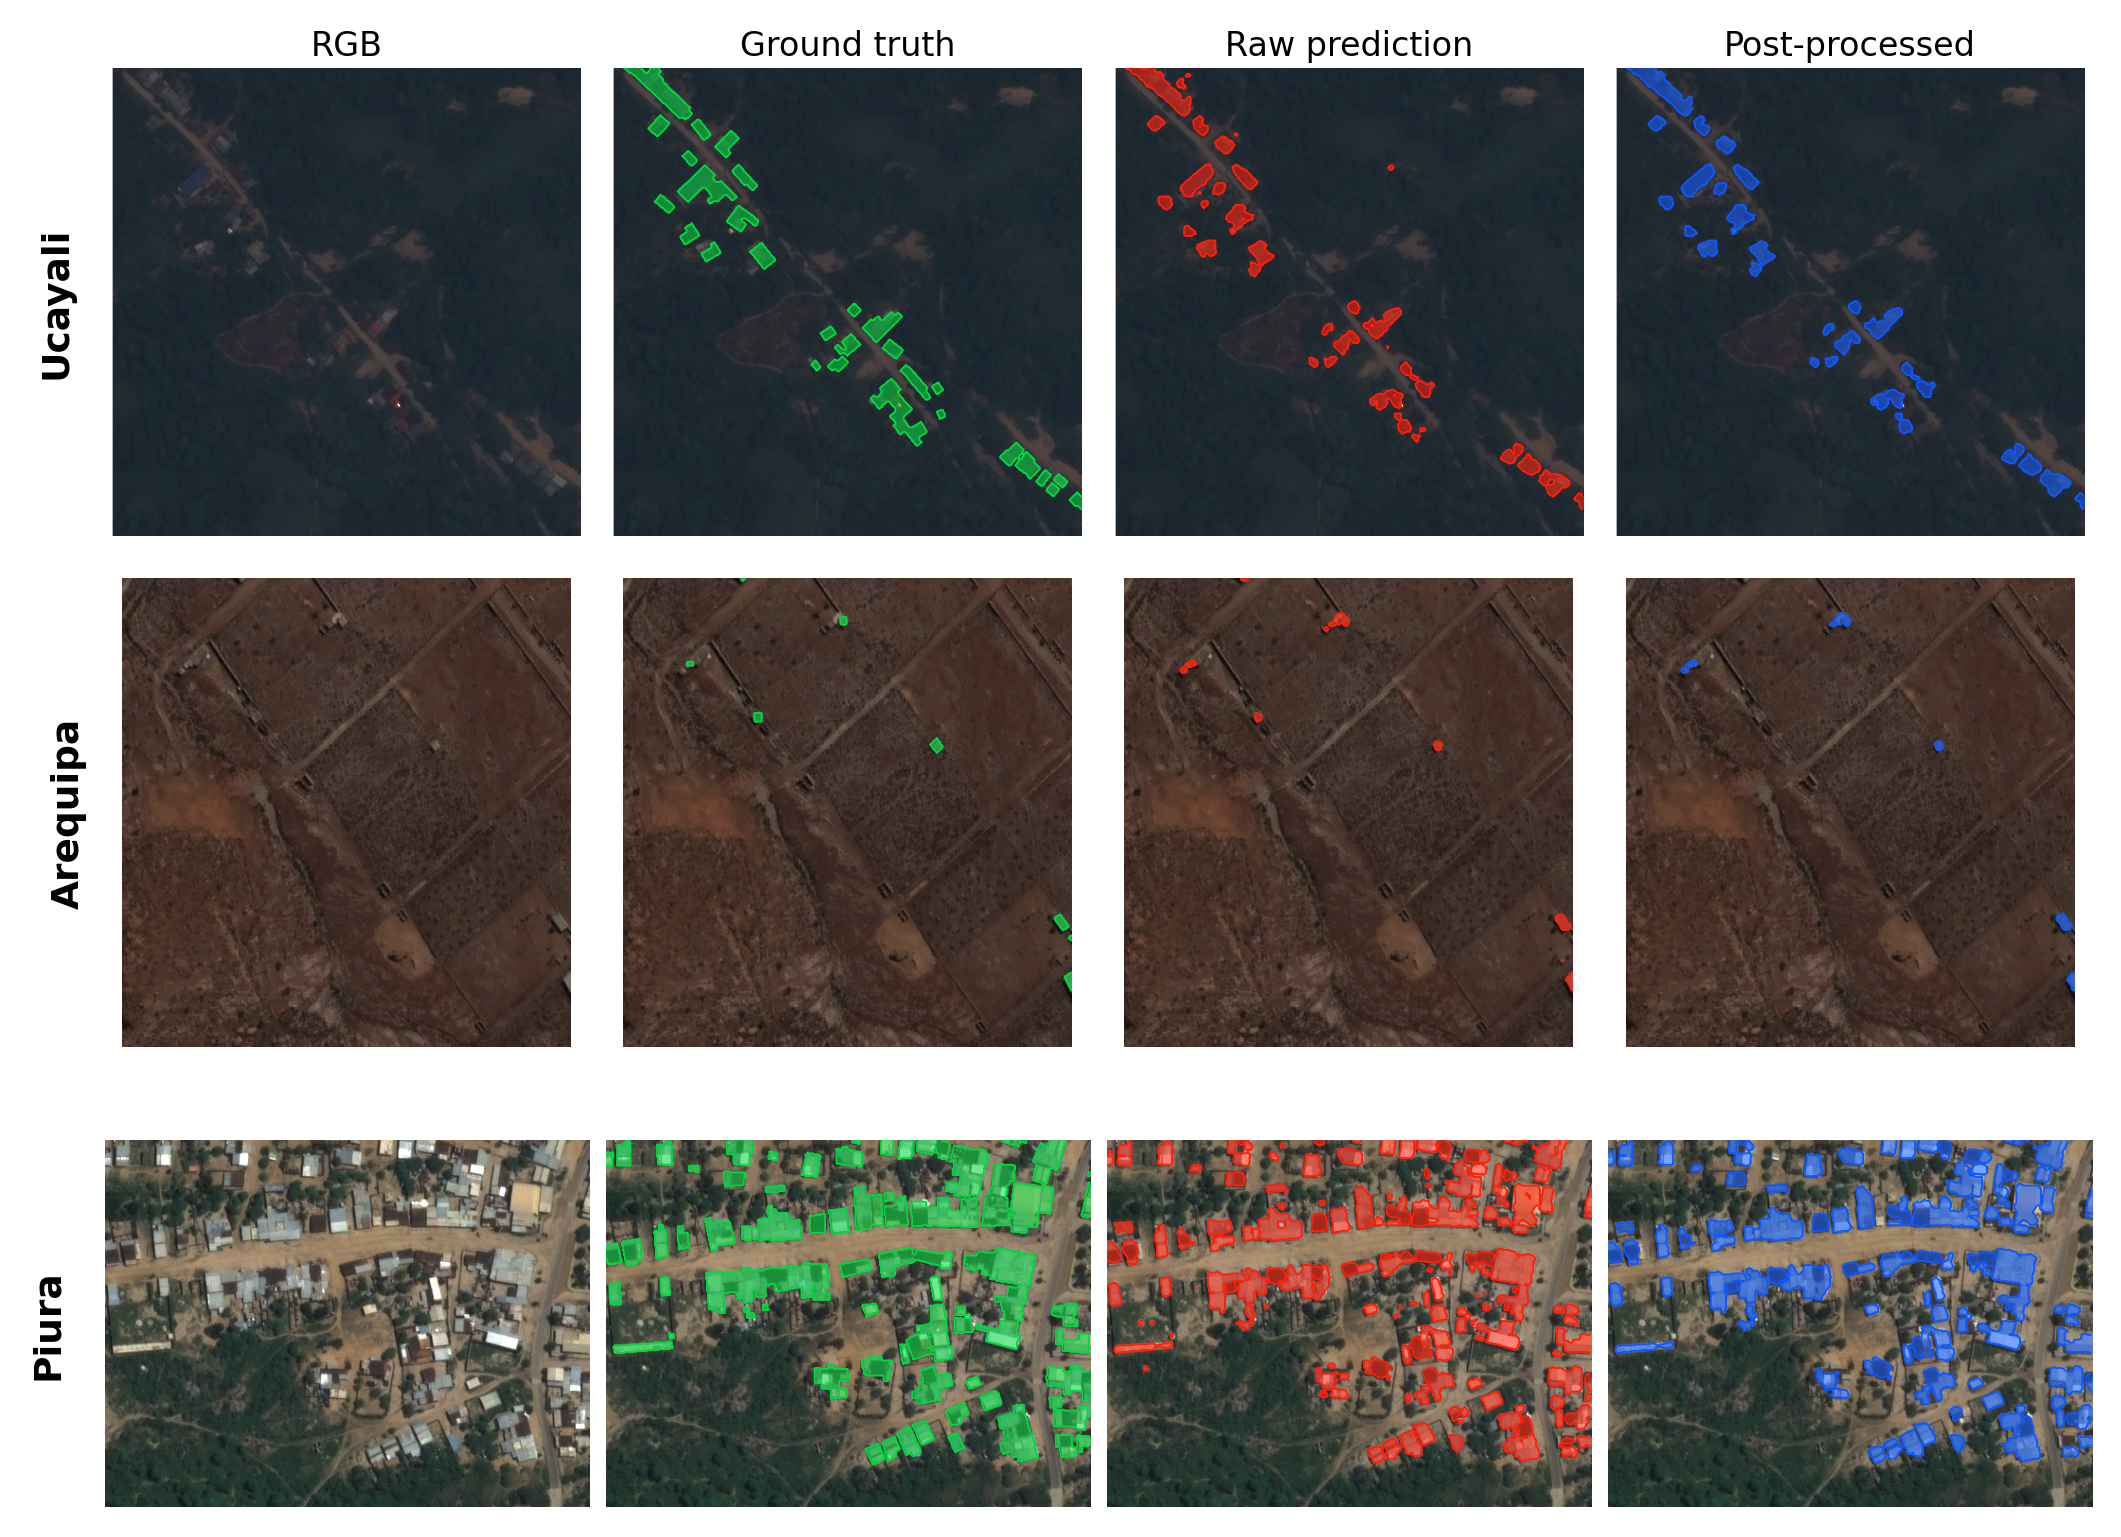

PDF: <PRIVATE_RUN_DIR>/paper_selected_figures/qualitative_results_ucayali_arequipa_piura_3x4.pdf
PNG: <PRIVATE_RUN_DIR>/paper_selected_figures/qualitative_results_ucayali_arequipa_piura_3x4.png


In [ ]:
import os
import re
import numpy as np
import torch
import matplotlib.pyplot as plt

SELECTED_QUALITATIVE_PATCHES = [
    {
        "department": "Ucayali",
        "patch_name": "img_IMG_PER1_20220828152001_ORT_PMS_000672_repasado_urbano_000066.tif",
    },
    {
        "department": "Arequipa",
        "patch_name": "img_IMG_PER1_20230531145858_ORT_PMS_000054_repasado_wilder_000634.tif",
    },
    {
        "department": "Piura",
        "patch_name": "img_IMG_PER1_20240306154256_ORT_PMS_000191_repasado_piura_urbano_000072.tif",
    },
]

USE_AUTO_CROP = True
CROP_MARGIN_PX = 45

QUALITATIVE_FIG_DIR = os.path.join(POSTPROCESS_RESULTS_DIR, "paper_selected_figures")
os.makedirs(QUALITATIVE_FIG_DIR, exist_ok=True)

def _safe_filename(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text)).strip("_")

def _as_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def _find_dataset_index_by_patch(dataset, patch_name):
    ids = [_dataset_patch_name(dataset, i) for i in range(len(dataset))]
    basenames = [os.path.basename(str(x)) for x in ids]

    if patch_name in basenames:
        return basenames.index(patch_name)

    matches = [i for i, name in enumerate(basenames) if patch_name in name or name in patch_name]
    if len(matches) == 1:
        return matches[0]

    raise ValueError(f"No encontre un match unico para: {patch_name}")

def _rgb_for_display(image_np, valid_mask):
    rgb = np.transpose(image_np[:3], (1, 2, 0)).astype(float)
    if rgb.max() > 1.5:
        rgb = rgb / 255.0
    rgb = np.clip(rgb, 0, 1)
    rgb = rgb.copy()
    rgb[~valid_mask] = 0.72
    return rgb

def _crop_slices_from_masks(masks, margin=45):
    union = np.zeros_like(masks[0], dtype=bool)
    for mask in masks:
        union |= mask.astype(bool)

    if not union.any():
        return slice(None), slice(None)

    ys, xs = np.where(union)
    y0 = max(int(ys.min()) - margin, 0)
    y1 = min(int(ys.max()) + margin + 1, union.shape[0])
    x0 = max(int(xs.min()) - margin, 0)
    x1 = min(int(xs.max()) + margin + 1, union.shape[1])
    return slice(y0, y1), slice(x0, x1)

def _overlay_mask(ax, rgb, mask, color_rgba):
    ax.imshow(rgb)
    layer = np.zeros((*mask.shape, 4), dtype=float)
    layer[mask.astype(bool)] = color_rgba
    ax.imshow(layer)
    if mask.any():
        ax.contour(mask.astype(float), levels=[0.5], colors=[color_rgba[:3]], linewidths=0.45)
    ax.axis("off")

postprocess_lookup = _build_postprocess_lookup_from_table(df_best_postprocess_by_origin)
dataset = test_loader.dataset
model2 = model2.to(DEVICE).eval()

rows = []

for item in SELECTED_QUALITATIVE_PATCHES:
    idx = _find_dataset_index_by_patch(dataset, item["patch_name"])

    image, y, valid = dataset[idx]
    image_np = _as_numpy(image)
    y_np = _as_numpy(y)
    valid_np = _as_numpy(valid)

    patch_name = _dataset_patch_name(dataset, idx)
    origin_name = _origin_name_from_patch(patch_name)

    if origin_name not in postprocess_lookup:
        raise ValueError(f"No hay configuracion de posproceso para origin_name={origin_name}")

    cfg = postprocess_lookup[origin_name]["cfg"]

    valid_mask = valid_np[0] > 0.5
    gt_mask = ((y_np[0] > 0.5) & valid_mask).astype(np.uint8)

    image_t = torch.as_tensor(image_np[None, :, :, :], device=DEVICE).float()
    valid_t = torch.as_tensor(valid_np[None, :, :, :], device=DEVICE).float()

    with torch.inference_mode():
        model_out = model2(image_t, valid_t)
        logits = model_out[0] if isinstance(model_out, (tuple, list)) else model_out
        prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()

    pred_raw = ((prob > cfg["threshold"]) & valid_mask).astype(np.uint8)
    pred_post = postprocess_prediction_mask(pred_raw, valid_mask.astype(np.uint8), cfg)

    rgb = _rgb_for_display(image_np, valid_mask)

    if USE_AUTO_CROP:
        ys, xs = _crop_slices_from_masks([gt_mask, pred_raw, pred_post], margin=CROP_MARGIN_PX)
        rgb = rgb[ys, xs]
        gt_mask = gt_mask[ys, xs]
        pred_raw = pred_raw[ys, xs]
        pred_post = pred_post[ys, xs]

    rows.append({
        "department": item["department"],
        "rgb": rgb,
        "gt": gt_mask,
        "raw": pred_raw,
        "post": pred_post,
    })

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(7.2, 5.4),
    dpi=300,
    constrained_layout=False,
)

column_titles = ["RGB", "Ground truth", "Raw prediction", "Post-processed"]
for col, title in enumerate(column_titles):
    axes[0, col].set_title(title, fontsize=8, pad=3)

for row_idx, row in enumerate(rows):
    axes[row_idx, 0].imshow(row["rgb"])
    axes[row_idx, 0].axis("off")

    _overlay_mask(axes[row_idx, 1], row["rgb"], row["gt"], (0.0, 0.85, 0.25, 0.55))
    _overlay_mask(axes[row_idx, 2], row["rgb"], row["raw"], (1.0, 0.12, 0.04, 0.55))
    _overlay_mask(axes[row_idx, 3], row["rgb"], row["post"], (0.05, 0.35, 1.0, 0.55))

    axes[row_idx, 0].text(
        -0.08, 0.5, row["department"],
        transform=axes[row_idx, 0].transAxes,
        rotation=90,
        va="center",
        ha="right",
        fontsize=9,
        fontweight="bold",
    )

plt.subplots_adjust(
    left=0.075,
    right=0.995,
    top=0.94,
    bottom=0.02,
    wspace=0.035,
    hspace=0.09,
)

pdf_path = os.path.join(QUALITATIVE_FIG_DIR, "qualitative_results_ucayali_arequipa_piura_3x4.pdf")
png_path = os.path.join(QUALITATIVE_FIG_DIR, "qualitative_results_ucayali_arequipa_piura_3x4.png")

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

print("PDF:", pdf_path)
print("PNG:", png_path)